In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/occupancy.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/distance.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/e_price.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/adj.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/volume-11kW.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/s_price.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/inf.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/weather_airport.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/poi.csv
/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone/duration.csv


**Initial Exploratory Data Analysis**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#base path
BASE = '/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone'

#loading files
occupancy = pd.read_csv(f'{BASE}/occupancy.csv', index_col =0)
duration = pd.read_csv(f'{BASE}/duration.csv', index_col =0)
volume = pd.read_csv(f'{BASE}/volume-11kW.csv', index_col =0)
e_price = pd.read_csv(f'{BASE}/e_price.csv', index_col =0)
s_price = pd.read_csv(f'{BASE}/s_price.csv', index_col =0)
weather  = pd.read_csv(f'{BASE}/weather_airport.csv')
adj = pd.read_csv(f'{BASE}/adj.csv', index_col =0, header=0)
distance = pd.read_csv(f'{BASE}/distance.csv', index_col =0, header=0)
inf = pd.read_csv(f'{BASE}/inf.csv')
poi = pd.read_csv(f'{BASE}/poi.csv')


#data shape
print("=== Dataset Shapes ===")
for name, df in [('occupancy', occupancy),
                ('duration', duration),
                ('volume', volume),
                ('e_price', e_price),
                ('s_price', s_price),
                ('weather', weather),
                ('adj', adj),
                ('distance', distance),
                ('inf', inf),
                ('poi', poi)]:
    print(f'{name: <12} {str(df.shape):<20}')

=== Dataset Shapes ===
occupancy    (4344, 275)         
duration     (4344, 275)         
volume       (4344, 275)         
e_price      (4344, 275)         
s_price      (4344, 275)         
weather      (4344, 7)           
adj          (275, 274)          
distance     (275, 274)          
inf          (1362, 7)           
poi          (712135, 3)         


**Inspecting Time Index**

In [3]:
print("=== Occupancy Sample (first 3 rows, 5 cols) ===")
print(occupancy.iloc[:3, :5])
print(f"\nTime steps: {len(occupancy)}")
print(f"Zones: {occupancy.shape[1]}")
print(f"\nIndex sample: {occupancy.index[:5].tolist()}")

=== Occupancy Sample (first 3 rows, 5 cols) ===
                      102  104   105   106   107
time                                            
2022-09-01 00:00:00  17.0  1.0  15.0  54.0  23.0
2022-09-01 01:00:00  16.0  1.0  19.0  50.0  25.0
2022-09-01 02:00:00  16.0  1.0  20.0  44.0  24.0

Time steps: 4344
Zones: 275

Index sample: ['2022-09-01 00:00:00', '2022-09-01 01:00:00', '2022-09-01 02:00:00', '2022-09-01 03:00:00', '2022-09-01 04:00:00']


**Dealing with missing values**

In [4]:
print("=== Missing values per dataframe ===")
for name, df in [('occupancy', occupancy),
                ('duration', duration),
                ('volume', volume),
                ('weather', weather),
                ('inf', inf)]:
    missingVal = df.isnull().sum().sum()
    pct = 100 * missingVal / df.size
    print(f'{name:<12} {missingVal:>6} missingVal ({pct:.2f}%)')

=== Missing values per dataframe ===
occupancy         0 missingVal (0.00%)
duration          0 missingVal (0.00%)
volume            0 missingVal (0.00%)
weather           0 missingVal (0.00%)
inf               0 missingVal (0.00%)


**Temporal Demand Patterns**

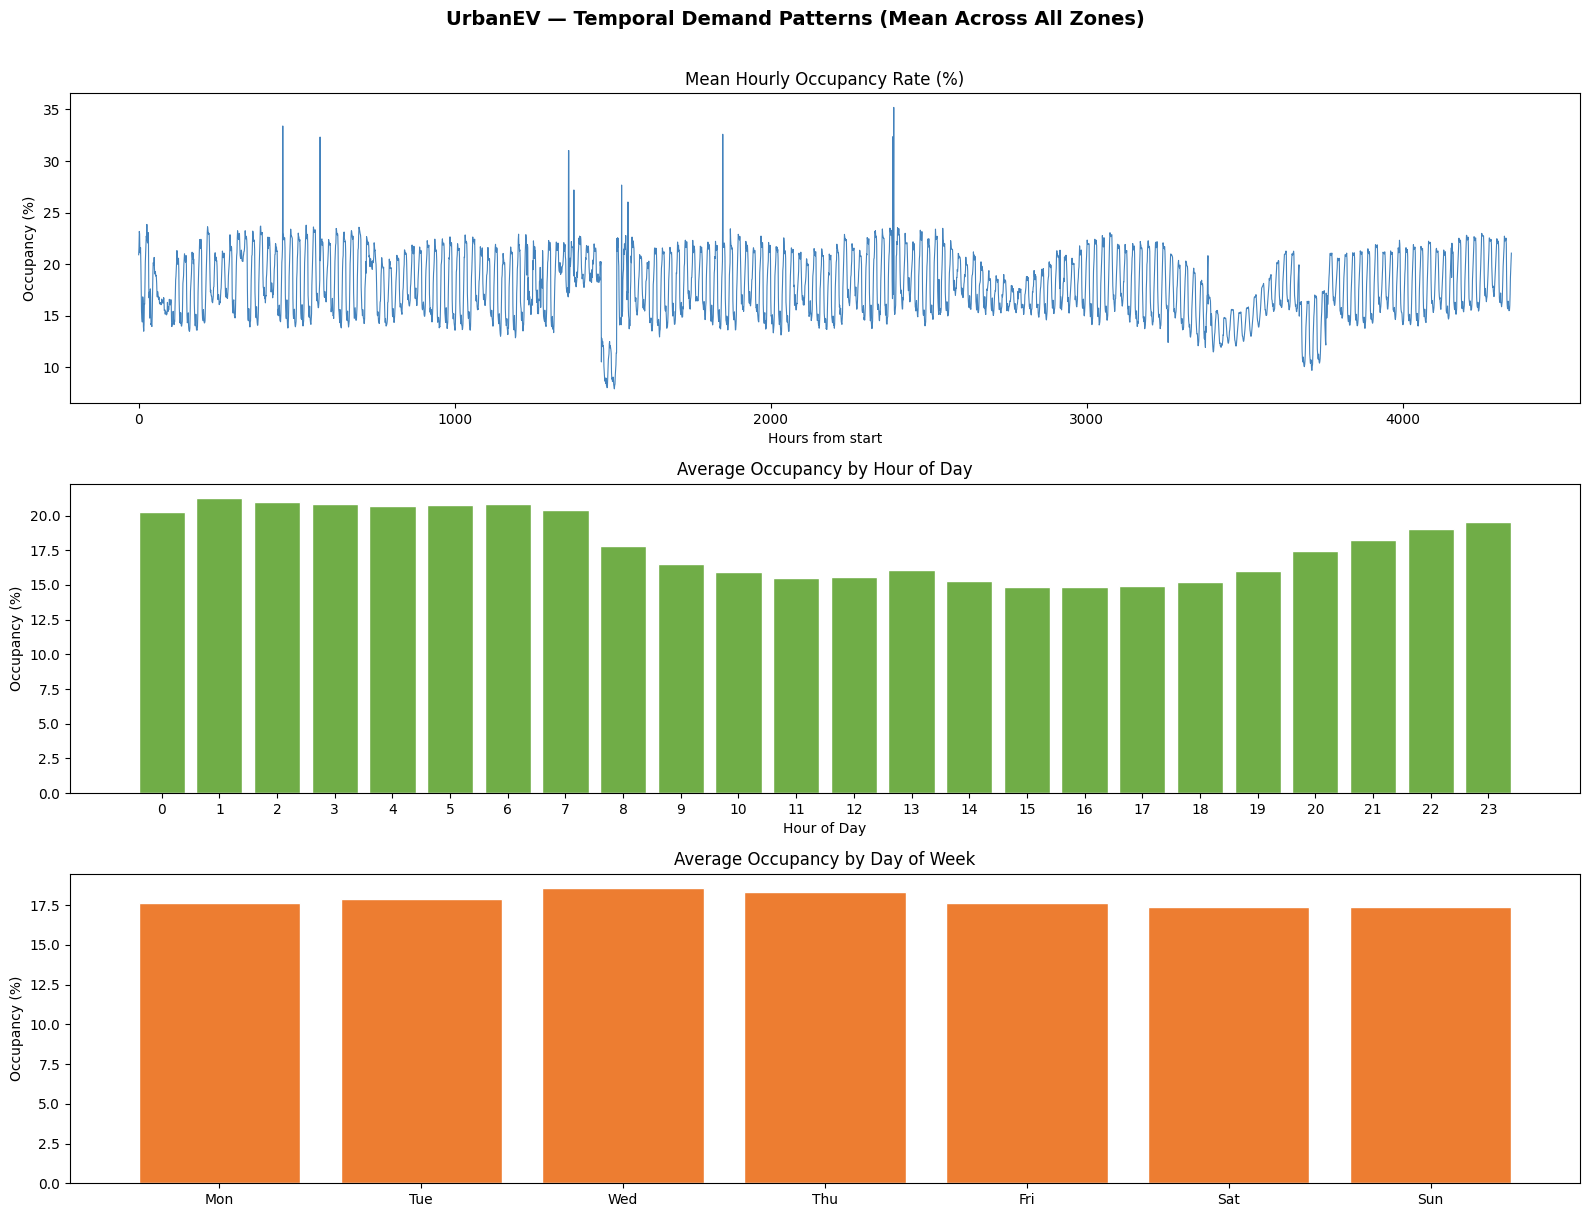

Saved: temporal_patterns.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('UrbanEV — Temporal Demand Patterns (Mean Across All Zones)',
             fontsize=14, fontweight='bold', y=1.01)

# Mean occupancy over time
mean_occ = occupancy.mean(axis=1)
axes[0].plot(mean_occ.values, color='#2E75B6', linewidth=0.8, alpha=0.9)
axes[0].set_title('Mean Hourly Occupancy Rate (%)')
axes[0].set_ylabel('Occupancy (%)')
axes[0].set_xlabel('Hours from start')

# Hourly pattern (average by hour of day)
mean_occ_indexed = mean_occ.copy()
mean_occ_indexed.index = range(len(mean_occ))
hourly = mean_occ.values.reshape(-1, 24).mean(axis=0)
axes[1].bar(range(24), hourly, color='#70AD47', edgecolor='white')
axes[1].set_title('Average Occupancy by Hour of Day')
axes[1].set_ylabel('Occupancy (%)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_xticks(range(24))

# Weekly pattern (average by day of week, starting Monday)
n_complete_weeks = len(mean_occ) // (24 * 7)
weekly_data = mean_occ.values[:n_complete_weeks * 24 * 7].reshape(-1, 7 * 24).mean(axis=0)
daily_avg = weekly_data.reshape(7, 24).mean(axis=1)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[2].bar(days, daily_avg, color='#ED7D31', edgecolor='white')
axes[2].set_title('Average Occupancy by Day of Week')
axes[2].set_ylabel('Occupancy (%)')

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: temporal_patterns.png")

**Spatial demand distribution**

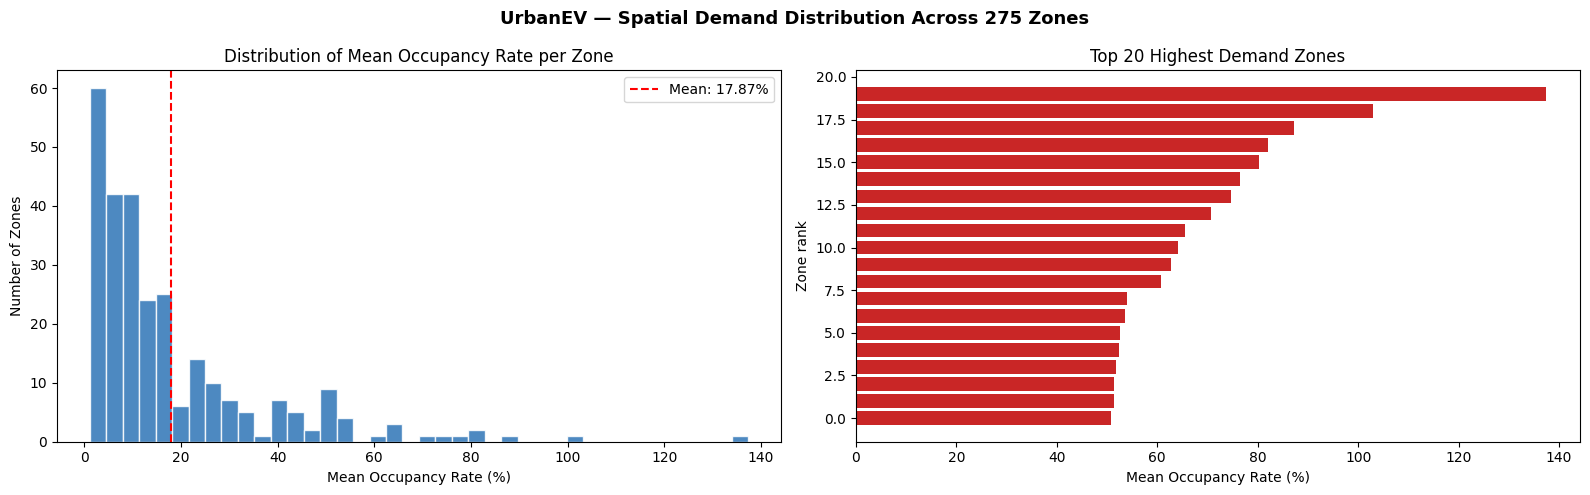


Zone occupancy stats:
  Mean:   17.866%
  Std:    19.229%
  Min:    1.163%
  Max:    137.305%
  Zones > 50% avg occupancy: 21


In [6]:
# Mean occupancy per zone across entire period
zone_mean_occ = occupancy.mean(axis=0).values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('UrbanEV — Spatial Demand Distribution Across 275 Zones',
             fontsize=13, fontweight='bold')

# Distribution of mean occupancy per zone
axes[0].hist(zone_mean_occ, bins=40, color='#2E75B6', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Mean Occupancy Rate per Zone')
axes[0].set_xlabel('Mean Occupancy Rate (%)')
axes[0].set_ylabel('Number of Zones')
axes[0].axvline(zone_mean_occ.mean(), color='red', linestyle='--', label=f'Mean: {zone_mean_occ.mean():.2f}%')
axes[0].legend()

# Top 20 and bottom 20 zones
sorted_idx = np.argsort(zone_mean_occ)
axes[1].barh(range(20), zone_mean_occ[sorted_idx[-20:]], color='#C00000', alpha=0.85)
axes[1].set_title('Top 20 Highest Demand Zones')
axes[1].set_xlabel('Mean Occupancy Rate (%)')
axes[1].set_ylabel('Zone rank')

plt.tight_layout()
plt.savefig('spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nZone occupancy stats:")
print(f"  Mean:   {zone_mean_occ.mean():.3f}%")
print(f"  Std:    {zone_mean_occ.std():.3f}%")
print(f"  Min:    {zone_mean_occ.min():.3f}%")
print(f"  Max:    {zone_mean_occ.max():.3f}%")
print(f"  Zones > 50% avg occupancy: {(zone_mean_occ > 50).sum()}")

**Feature Correlation**

inf.csv columns: ['station_id', 'longitude', 'latitude', 'charge_count', 'TAZID', 'area', 'perimeter']
poi.csv columns: ['primary_types', 'longitude', 'latitude']


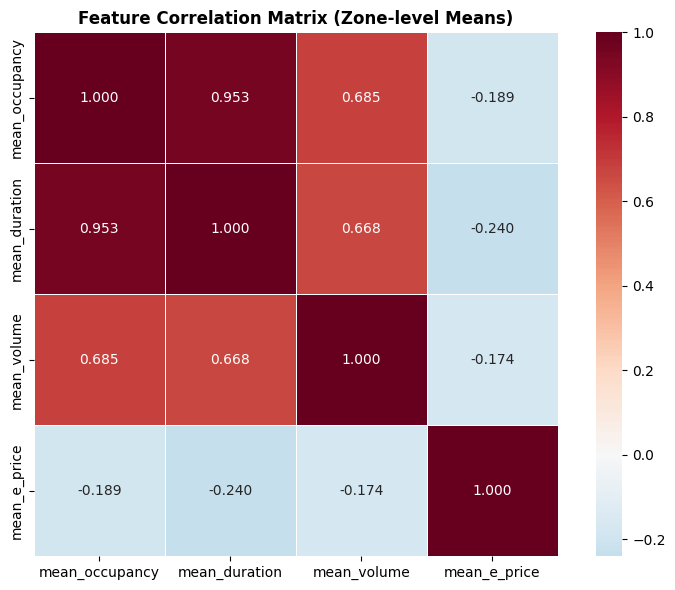

In [7]:
# zone-level feature summary for correlation analysis
zone_features = pd.DataFrame({
    'mean_occupancy':  occupancy.mean(axis=0).values,
    'mean_duration':   duration.mean(axis=0).values,
    'mean_volume':     volume.mean(axis=0).values,
    'mean_e_price':    e_price.mean(axis=0).values,
})

# Add inf features 
print("inf.csv columns:", inf.columns.tolist())
print("poi.csv columns:", poi.columns.tolist())

corr = zone_features.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (Zone-level Means)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Summary statistics**

In [8]:
print("=" * 55)
print("  URBANEV Dataset Summary — Thesis Reference")
print("=" * 55)
print(f"  Zones:              {occupancy.shape[1]}")
print(f"  Time steps (hours): {occupancy.shape[0]}")
print(f"  Period (approx):    {occupancy.shape[0] / 24 / 30:.1f} months")
print(f"  Features loaded:    10")
print(f"\n  Occupancy range:    {occupancy.values.min():.2f}% – {occupancy.values.max():.2f}%")
print(f"  Mean occupancy:     {occupancy.values.mean():.3f}%")
print(f"  Zones > 50% mean:   {(occupancy.mean(axis=0) > 50).sum()}")
print(f"\n  Adjacency matrix:   {adj.shape}")
print(f"  Distance matrix:    {distance.shape}")
print(f"  POI entries:        {len(poi)}")
print("=" * 55)
print("\nEDA complete. Save this notebook as Version 1.")

  URBANEV Dataset Summary — Thesis Reference
  Zones:              275
  Time steps (hours): 4344
  Period (approx):    6.0 months
  Features loaded:    10

  Occupancy range:    0.00% – 373.00%
  Mean occupancy:     17.866%
  Zones > 50% mean:   21

  Adjacency matrix:   (275, 274)
  Distance matrix:    (275, 274)
  POI entries:        712135

EDA complete. Save this notebook as Version 1.
